In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 16               # 본문 크기
mpl.rcParams['axes.labelsize'] = 18         # 축 라벨
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['mathtext.fontset'] = 'cm'      # LaTeX 수식은 Computer Modern 유지
mpl.rcParams['axes.linewidth'] = 1.0   

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def poisson_kernel(theta, r, psi=0.0):
    """
    OA subpopulation density centered at psi.
    
    f(theta) = (1-r^2) / [2π(1 - 2r cos(theta-psi) + r^2)]
    
    r=1 corresponds to a delta peak, so for plotting use r slightly smaller
    than 1, e.g. r=0.995.
    """
    th = theta - psi
    return (1 - r**2) / (2 * np.pi * (1 - 2*r*np.cos(th) + r**2))


def dist_bimodal_mixture(theta, r, eta, psi=0.0):
    """
    Current bimodal OA distribution using the paper's eta convention.

    This version matches the closed-form expression with coefficient (1-2*eta).
    Peaks are located at psi and psi+pi.

    eta = 0.5  -> symmetric bimodal distribution, R=0
    eta != 0.5 -> symmetry-broken bimodal distribution, R=(1-2*eta)r
    """
    f_plus = poisson_kernel(theta, r, psi=psi)
    f_minus = poisson_kernel(theta, r, psi=psi + np.pi)

    # This weighting gives the odd harmonic coefficient (1 - 2*eta)
    f = (1 - eta) * f_plus + eta * f_minus
    return np.real(f)


def dist_bimodal_closed(theta, r, eta, psi=0.0):
    """
    Closed-form density corresponding to Eq. (S7).

    f = 1/(2π) * [1 + 2{(1-2η)r(1-r^2)cos(θ-ψ)
                      + r^2 cos(2(θ-ψ)) - r^4}
                     /(1 - 2r^2 cos(2(θ-ψ)) + r^4)]
    """
    th = theta - psi
    c1 = np.cos(th)
    c2 = np.cos(2 * th)

    den = 1 - 2 * r**2 * c2 + r**4
    num = (1 - 2*eta) * r * (1 - r**2) * c1 + r**2 * c2 - r**4

    f = (1 / (2 * np.pi)) * (1 + 2 * num / den)
    return np.real(f)

In [14]:
x = np.linspace(-np.pi/2, 3*np.pi/2, 50000)
r1_plot = 0.99999
pdf1 = dist_bimodal_closed(x, r1_plot, eta1, psi=0.0)

([<matplotlib.axis.XTick at 0x1d3e9256550>,
 [Text(0.0, 0, '0'), Text(3.141592653589793, 0, '$\\pi$')])

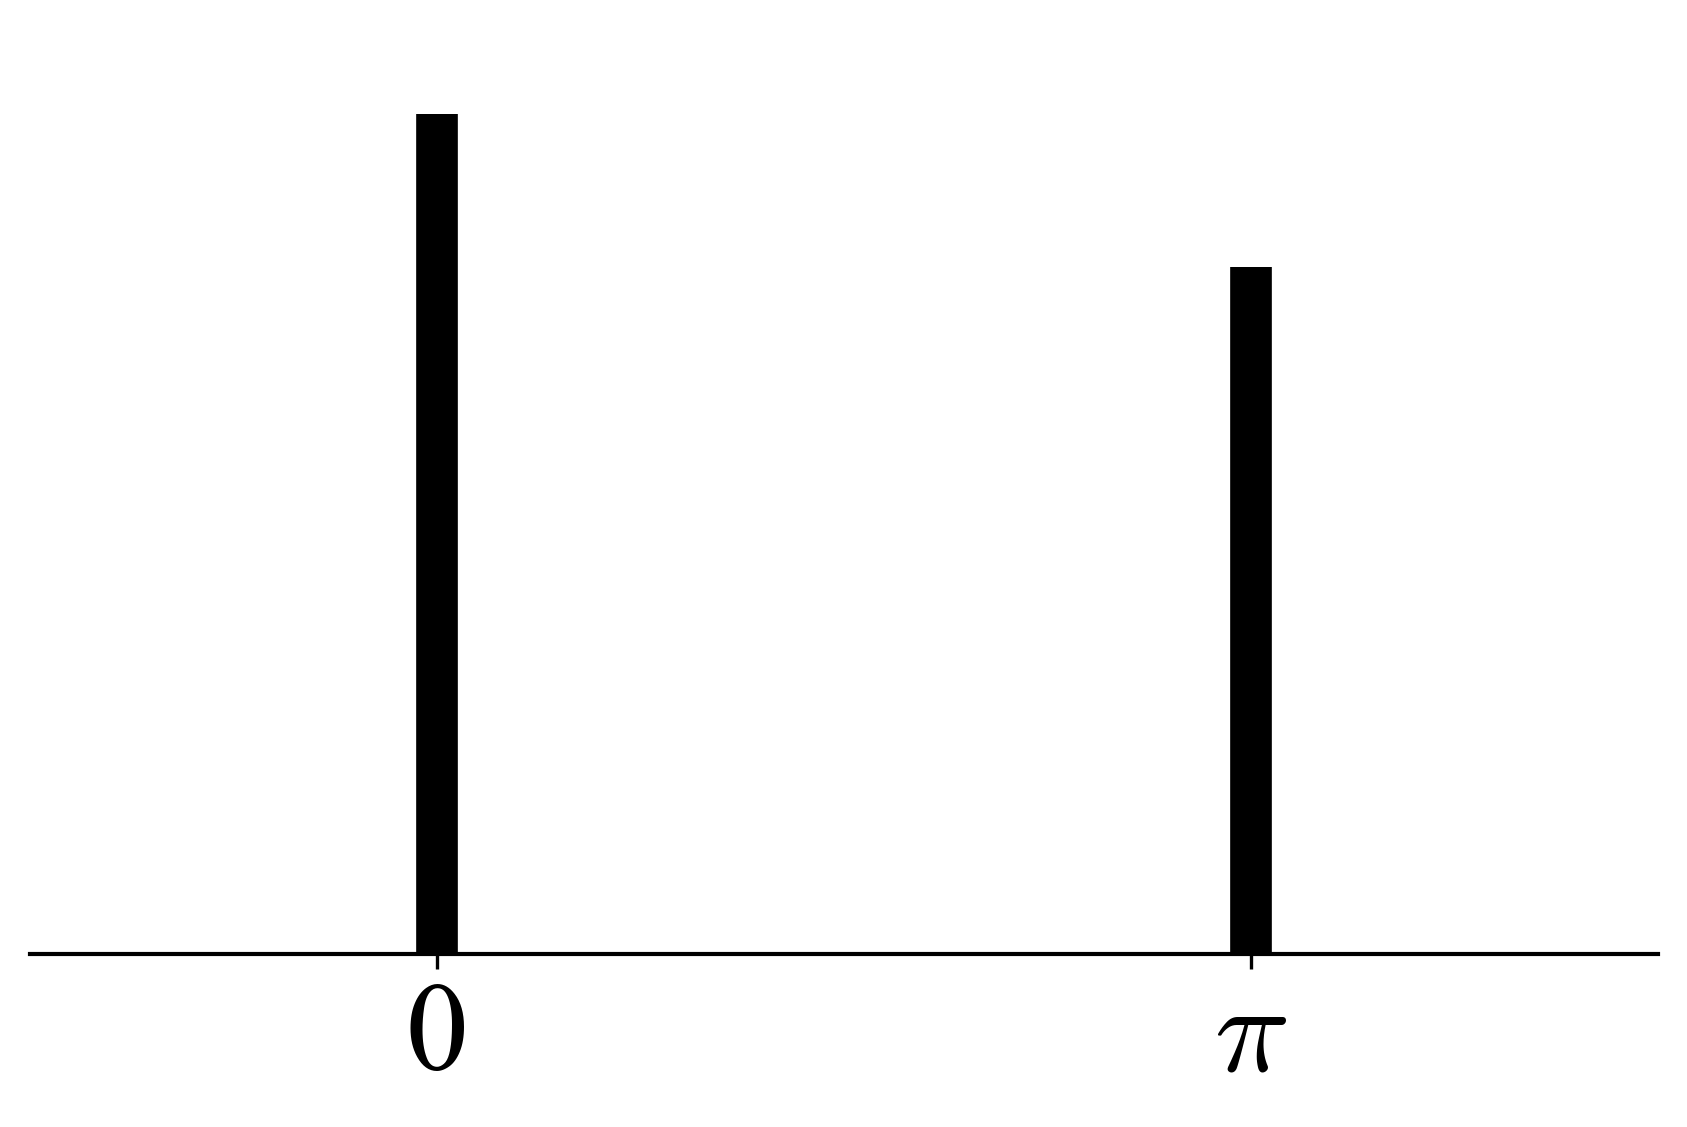

In [36]:
eta1 = 0.45

# 두 peak의 상대 weight
w0 = 1 - eta1   # at theta = 0
wpi = eta1      # at theta = pi

weights = np.array([w0, wpi])
weights = weights / np.max(weights)
plt.figure(figsize=(7,4),dpi=300)
plt.vlines([0, np.pi], [0, 0], weights, color='black', lw=10)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.yticks([])
plt.ylim(0,1.1)
plt.xlim(-np.pi/2,3*np.pi/2)
plt.xticks([0,np.pi],[0,r'$\pi$'],fontsize=30)

([<matplotlib.axis.XTick at 0x1d3e52156d0>,
 [Text(0.0, 0, '0'), Text(3.141592653589793, 0, '$\\pi$')])

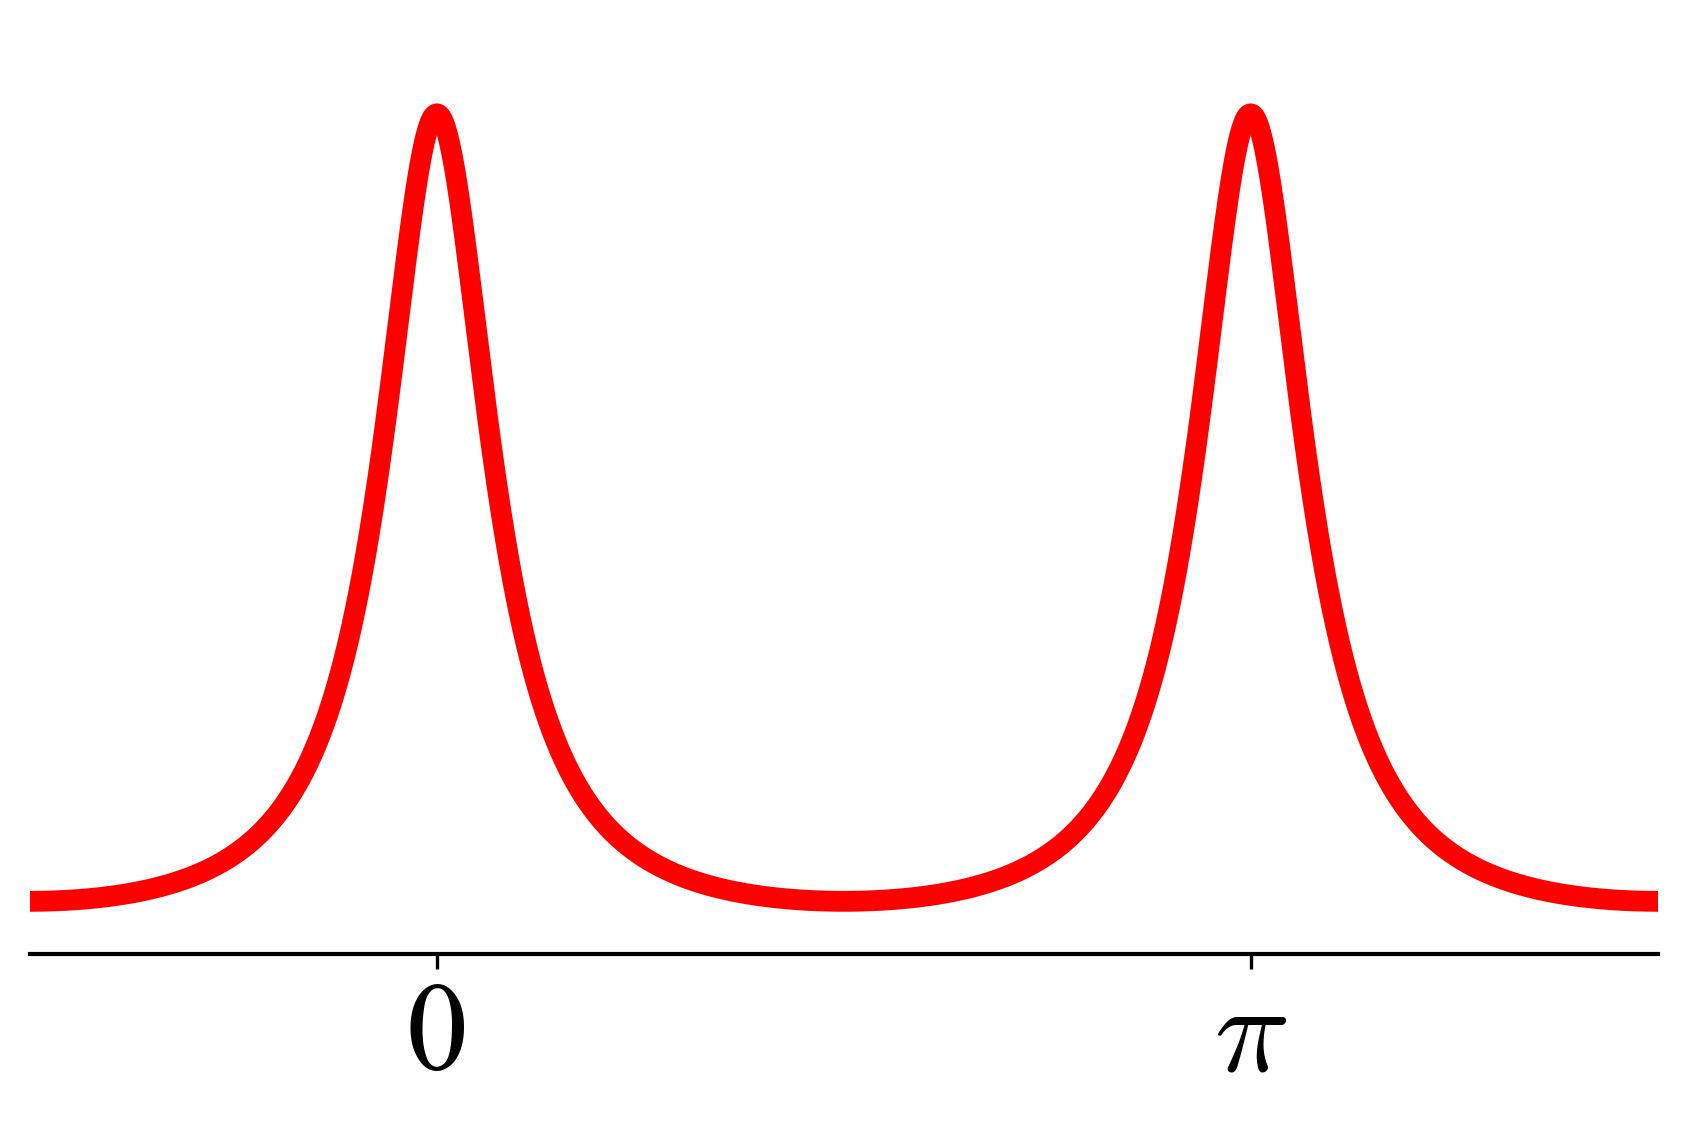

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def dist_bimodal_closed(theta, r, eta, psi=0.0):
    th = theta - psi
    den = 1 - 2*r**2*np.cos(2*th) + r**4
    num = (1 - 2*eta)*r*(1 - r**2)*np.cos(th) + r**2*np.cos(2*th) - r**4
    f = (1/(2*np.pi)) * (1 + 2*num/den)
    return np.real(f)

x = np.linspace(-np.pi/2, 3*np.pi/2, 200000)

eta2 = 0.5
Q2 = 0.6
r2 = np.sqrt(Q2)

pdf2 = dist_bimodal_closed(x, r2, eta2)
pdf2 = pdf2 / np.max(pdf2)
plt.figure(figsize=(7,4),dpi=300)

plt.plot(x, pdf2, color='red', lw=5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.yticks([])
plt.ylim(0,1.1)
plt.xlim(-np.pi/2,3*np.pi/2)
plt.xticks([0,np.pi],[0,r'$\pi$'],fontsize=30)

# FIG 3

C:\Users\kim9y\AppData\Local\Temp\ipykernel_12348\4150037588.py:40: RuntimeWarning: invalid value encountered in sqrt
  rho_fp = (B - np.sqrt(B**2 - A**2)) / A


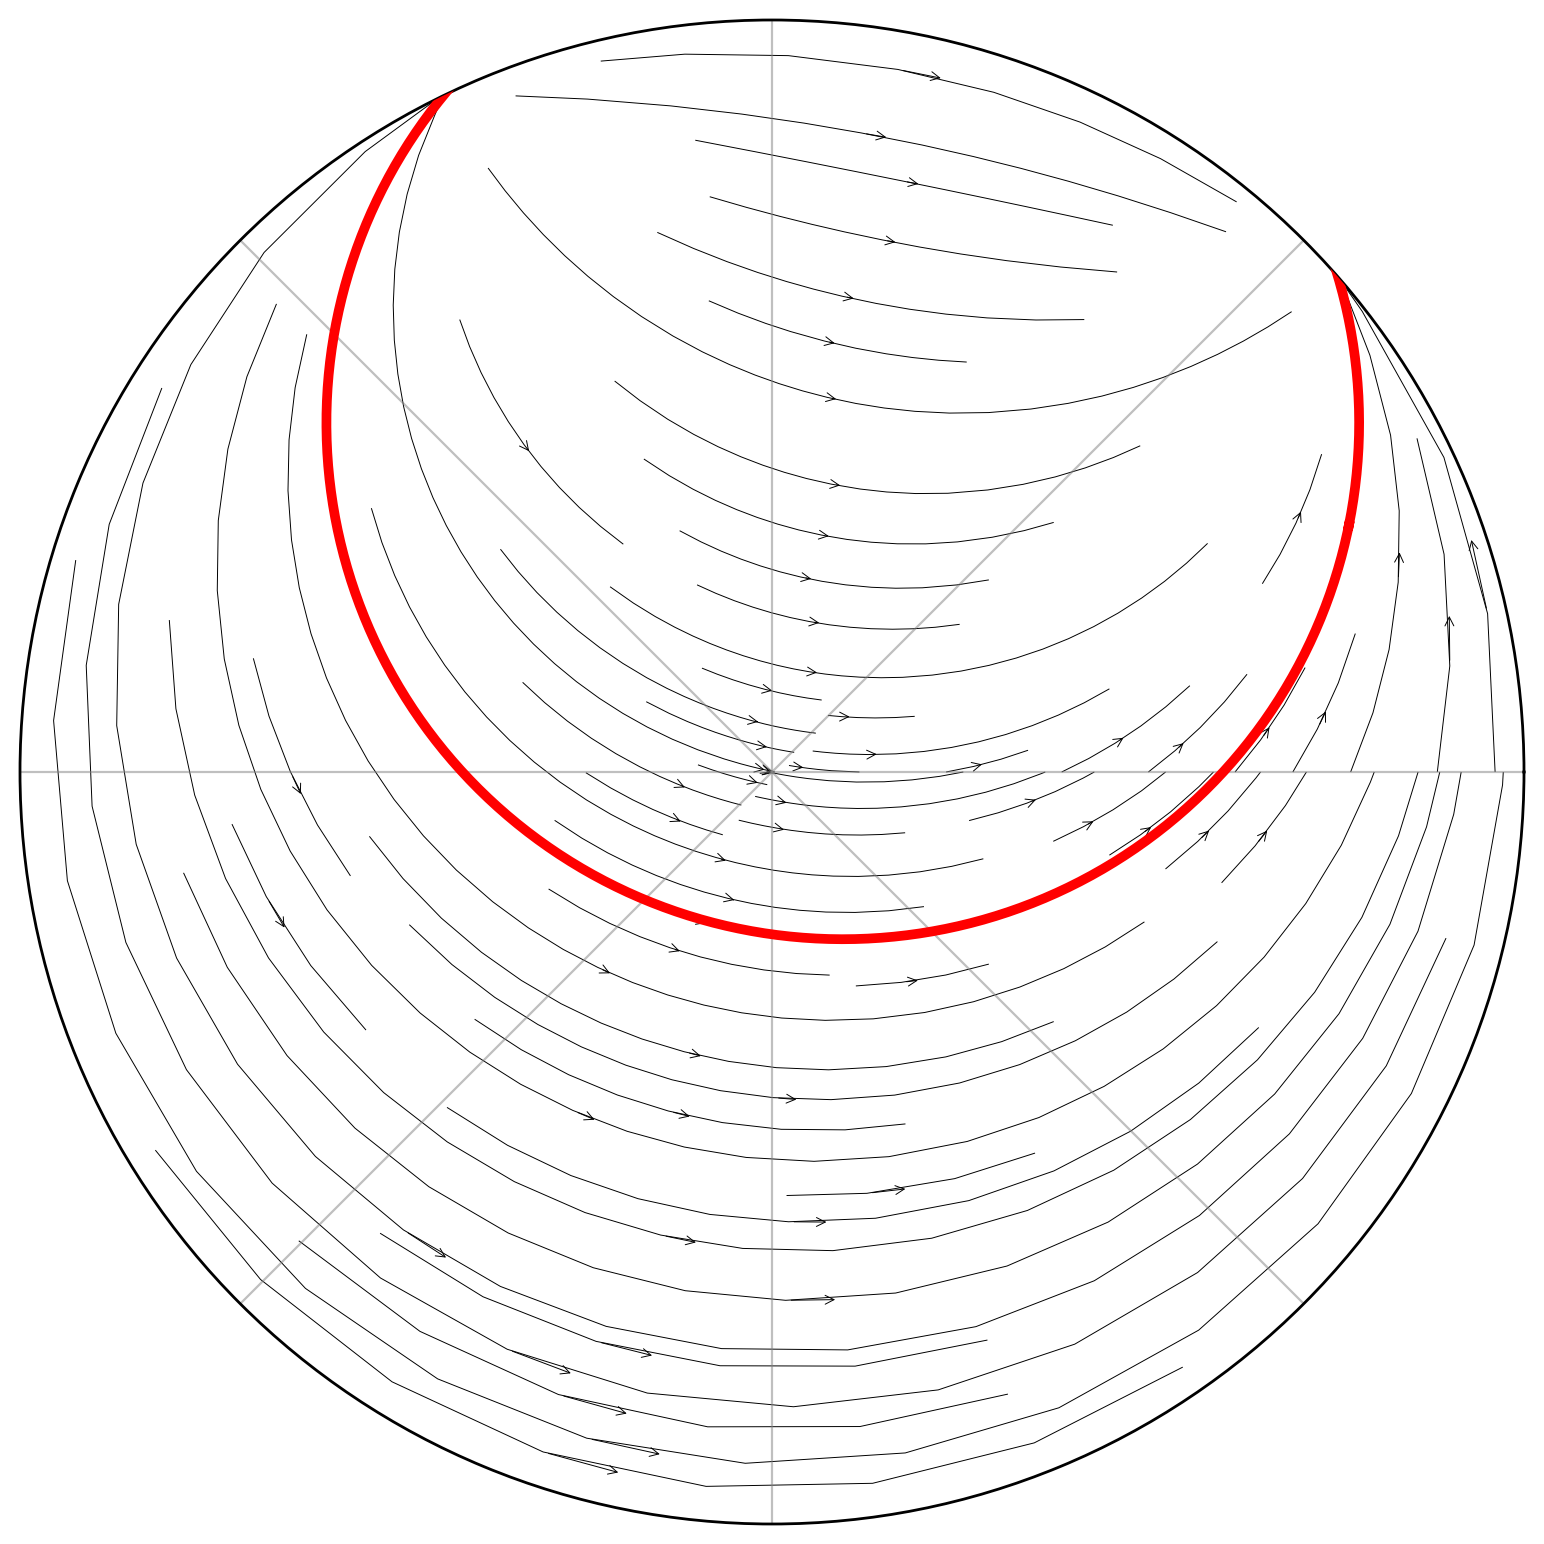

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 파라미터 및 초기 조건 설정
# ==========================================
alpha = 0.2
mu = 0.5          
eta = 0.1         

A = (mu**2) * (1 - 2*eta)**2
B = np.sin(alpha) * (1 - 2*eta)**2

# 궤도 보존량 C_0를 구하기 위한 초기 상태
Q_init = 0.6
phi_init = 0.0

# ==========================================
# 2. Z_2의 해석적 해 (Analytical Solution) 도출 
# - ODE 시뮬레이션(RK45)을 전혀 사용하지 않습니다!
# ==========================================
# (1) 초기 상태를 바탕으로 불변량 C_0 계산
Y_init = Q_init * np.sin(2 * phi_init + alpha)
C_0 = (np.sin(alpha) - mu**2 * Y_init) / (1 - Q_init**2)

# (2) 위상 공간에서 형성되는 완벽한 원의 중심과 반지름
Center_Y = (mu**2) / (2 * C_0)
Radius = np.sqrt(mu**4 - 4 * C_0 * (np.sin(alpha) - C_0)) / (2 * C_0)

# (3) 0 ~ 2pi를 도는 매개변수로 원 궤적(Z) 생성
theta_circ = np.linspace(0, 2*np.pi, 500)
# 중심이 허수축(Y)에 Center_Y만큼 치우친 반경 Radius의 원
Z_analytical = 1j * Center_Y + Radius * np.exp(1j * theta_circ)

# (4) Z를 Z_2 극좌표계(Q, 2*phi)로 완벽 매핑
Q_exact = np.abs(Z_analytical)
Theta_exact = np.unwrap(np.angle(Z_analytical)) - alpha

# 고정점(Center)도 해석적으로 계산
rho_fp = (B - np.sqrt(B**2 - A**2)) / A
theta_fp = np.pi/2 - alpha

# ==========================================
# 3. 위상 공간 시각화 (Polar Phase Space Plot)
# ==========================================
# (배경 Streamplot용 그리드 생성 - 이전과 동일)
theta_grid = np.linspace(0, 2*np.pi, 1000)
rho_grid = np.linspace(0.001, 1.0, 1000)
T, R_grid = np.meshgrid(theta_grid, rho_grid)
dRho = A * (1 - R_grid**2) * np.cos(T + alpha)
dTheta = -A * ((1 + R_grid**2) / R_grid) * np.sin(T + alpha) + 2 * B

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8), dpi=200)

# 배경 유선 (Streamlines)
ax.streamplot(
    T, R_grid, dTheta, dRho,
    color='k',
    linewidth=0.35,
    density=0.9,
    arrowstyle='->',
    arrowsize=0.8,
    zorder=1
)

# ★ 미분방정식 수치해석 없이 닫힌 수식으로 그린 완벽한 Limit cycle 궤적 ★
ax.plot(Theta_exact % (2*np.pi), Q_exact, color='red', linewidth=3.5, zorder=4)

# 고정점(Center) 마킹 (빈 동그라미)
ax.scatter(theta_fp, rho_fp, s=80, facecolors='none', edgecolors='red', linewidths=2.5, zorder=6)


# 그래프 스타일링
ax.set_ylim(0, 1.0) 
ax.set_yticks([])   
ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 6*np.pi/4, 7*np.pi/4])
ax.set_xticklabels(['', '', '', '', '', '', '', '']) 
ax.grid(True, linestyle='-', color='gray', alpha=0.5)

plt.tight_layout()
plt.show()

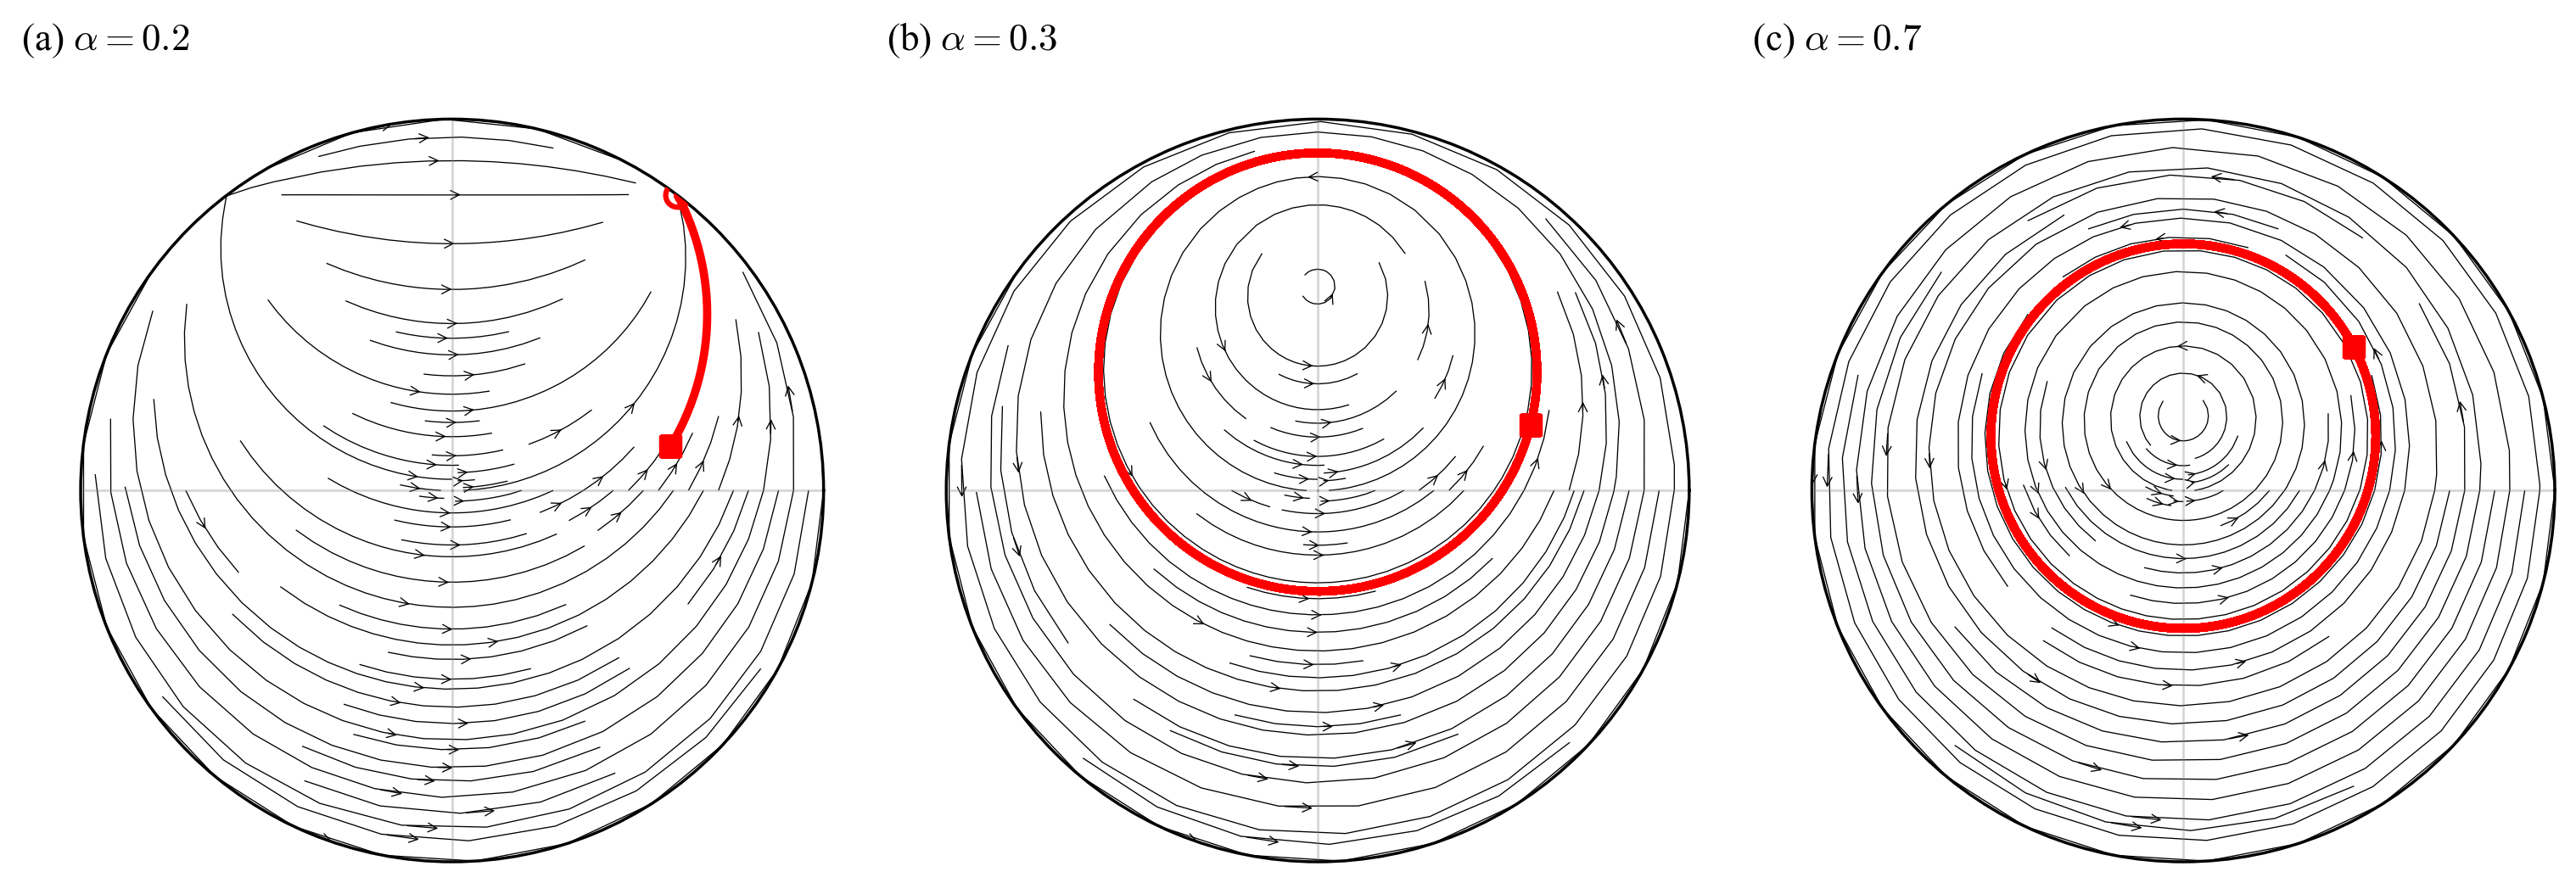

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =========================================================
# 1. Parameters from the manuscript
# =========================================================
mu = 0.5
eta1 = 0.45
Q2_init = 0.6
phi_init = 0.0

alphas = [0.2, 0.3, 0.7]
eta = eta1

t_max = 40000
n_eval = 6000
t_eval = np.linspace(0, t_max, n_eval)


# =========================================================
# 2. Reduced dynamics in (Q, Phi)
# Q = r^2, Phi = 2 phi + alpha
# =========================================================
def reduced_QPhi(t, y, alpha, mu, eta):
    Q, Phi = y
    Q = max(Q, 1e-8)

    A = mu**2 * (1 - 2 * eta)**2
    B = np.sin(alpha) * (1 - 2 * eta)**2

    dQ = A * (1 - Q**2) * np.cos(Phi)
    dPhi = -A * ((1 + Q**2) / Q) * np.sin(Phi) + 2 * B

    return [dQ, dPhi]


def get_trajectory(alpha):
    # Q2(0)=0.6 and phi(0)=0 -> Phi(0)=alpha
    y0 = [Q2_init, 2 * phi_init + alpha]

    sol = solve_ivp(
        reduced_QPhi,
        [0, t_max],
        y0,
        args=(alpha, mu, eta),
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-11,
        method='RK45'
    )

    Q = sol.y[0]
    Phi = sol.y[1]

    return sol.t, Q, Phi


# =========================================================
# 3. Background vector field
# =========================================================
def background_field(alpha, mu, eta, n_theta=160, n_q=120):
    theta_grid = np.linspace(0, 2 * np.pi, n_theta)
    q_grid = np.linspace(0.03, 1.0, n_q)

    T, Q = np.meshgrid(theta_grid, q_grid)

    A = mu**2 * (1 - 2 * eta)**2
    B = np.sin(alpha) * (1 - 2 * eta)**2

    dQ = A * (1 - Q**2) * np.cos(T)
    dTheta = -A * ((1 + Q**2) / Q) * np.sin(T) + 2 * B

    return T, Q, dTheta, dQ


# =========================================================
# 4. Synchronized fixed point on Q=1 branch
# =========================================================
def synchronized_fixed_point(alpha, mu):
    value = np.sin(alpha) / mu**2

    if np.abs(value) <= 1:
        Phi_star = np.arcsin(value)   # stable branch, cos(Phi*) > 0
        Q_star = 1.0
        return Q_star, Phi_star

    return None, None


# =========================================================
# 5. Plot
# =========================================================
fig, axes = plt.subplots(
    1, 3,
    subplot_kw={'projection': 'polar'},
    figsize=(12.5, 4.2),
    dpi=250
)

panel_labels = ['(a)', '(b)', '(c)']
alpha_c = np.arcsin(mu**2)

for ax, alpha, lab in zip(axes, alphas, panel_labels):

    # Background streamlines
    T, Q_grid, dTheta, dQ = background_field(alpha, mu, eta)

    ax.streamplot(
        T, Q_grid, dTheta, dQ,
        color='k',
        linewidth=0.38,
        density=0.85,
        arrowstyle='->',
        arrowsize=0.75,
        zorder=1
    )

    # Trajectory from manuscript initial condition
    t, Q_traj, Phi_traj = get_trajectory(alpha)

    ax.plot(
        Phi_traj % (2 * np.pi),
        Q_traj,
        color='red',
        linewidth=2.8,
        zorder=4
    )

    # Initial point
    ax.scatter(
        Phi_traj[0] % (2 * np.pi),
        Q_traj[0],
        color='red',
        s=45,
        marker='s',
        zorder=5
    )

    # Fixed point marker for synchronized regime
    if alpha < alpha_c:
        Q_fp, Phi_fp = synchronized_fixed_point(alpha, mu)

        if Q_fp is not None:
            ax.scatter(
                Phi_fp % (2 * np.pi),
                Q_fp,
                facecolors='none',
                edgecolors='red',
                linewidths=1.8,
                s=65,
                zorder=6
            )

    # Panel label, left aligned
    ax.text(
        -0.08, 1.08,
        rf'{lab} $\alpha={alpha}$',
        transform=ax.transAxes,
        fontsize=13,
        ha='left',
        va='bottom'
    )

    # Styling
    ax.set_ylim(0, 1.0)
    ax.set_yticks([])

    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    ax.set_xticklabels(['', '', '', ''])

    ax.grid(True, linestyle='-', color='gray', alpha=0.32)
    ax.spines['polar'].set_linewidth(1.0)

plt.tight_layout(w_pad=1.0)
plt.show()